# From Bag‑of‑Words to Mini‑Transformer: Sentiment on IMDB Reviews
*A reusable PyTorch workflow with Hugging Face datasets/tokenizers*  

This notebook implements a **Bag‑of‑Words (BoW) → MLP** baseline and a **Mini‑Transformer** trained from scratch for comparison.  
Hugging Face is used for **data** (and tokenizer for the transformer).

**Outline**
1. Intro & Imports  
2. Load & Inspect the Dataset (Hugging Face `datasets`)  
3. Data Preparation (BoW vectorizer + HF tokenizer; datasets & collate)  
4. Build a Baseline Model (BoW → MLP)  
5. Define Loss & Optimizer  
6. DataLoaders  
7. Training & Evaluation Loops  
8. Train Baseline Model  
9. Visualize Metrics  
10. Show Predictions  
11. Build an Improved Model (Mini‑Transformer)  
12. Compare MLP vs Mini‑Transformer  
13. Optimization Experiments (best weights, LR range test)  
14. Summary Markdown  
15. Optional Additions (schedulers, text aug, batch size, save/load)

## Imports

In [1]:
#
# colab install bits
# NOTE: run this,
# restart the kernel,
# then comment it out & run the notebook
#
#
# !pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
# !pip install -U transformers datasets accelerate evaluate scikit-learn
# !pip install -U rich matplotlib seaborn

In [2]:
# pip install numpy==1.26.4

In [3]:
#
# max number of "performance" cores on the mac I'm using
#

# import os
# os.environ["OMP_NUM_THREADS"] = "4"
# os.environ["MKL_NUM_THREADS"] = "4"

In [4]:
# Core
import os, re, math, random, copy, json, time
import numpy as np
import torch
import datasets
import transformers
from torch import nn
from torch.utils.data import DataLoader, Dataset

# ORDER HERE MATTERS, BEFORE TOKENIZERS
import os
# os.environ["TOKENIZERS_PARALLELISM"] = "false"  # or "true" if you prefer, set once before use

# HF datasets & tokenizers
from datasets import load_dataset, DatasetDict
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          DataCollatorWithPadding, TrainingArguments, Trainer, EarlyStoppingCallback)
# Plotting
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, precision_recall_fscore_support

In [5]:
device = "mps" if torch.backends.mps.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


In [6]:
print("datasets    :", datasets.__version__)

datasets    : 4.4.1


In [7]:
print("torch       :", torch.__version__)

torch       : 2.9.0+cu126


In [8]:
print("transformers:", transformers.__version__)

transformers: 4.57.3


In [9]:
print("device      :", "cuda" if torch.cuda.is_available()
      else ("mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available() else "cpu"))

device      : cuda


### For Colab Env

In [10]:
#
# for colab env
#
device = "mps" if torch.backends.mps.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


In [11]:
#
# for colab env
#
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
# ============================================
#  IMDB DATASET LOADING + TOKENIZATION (COLAB)
# ============================================

from datasets import load_dataset
from transformers import AutoTokenizer
import numpy as np

# ------------------------------
# Config (adjust as needed)
# ------------------------------
TRAIN_LIMIT_PT = 5000       # set None for full dataset
VAL_LIMIT_PT   = 2000
PRETRAINED_NAME = "distilroberta-base"
MAX_LEN = 256               # 128 for faster runs

print("Dataset limits:", TRAIN_LIMIT_PT, VAL_LIMIT_PT)
print("Tokenizer:", PRETRAINED_NAME)

# ------------------------------
# Load raw IMDB HF dataset
# ------------------------------
imdb = load_dataset("imdb")
print("Raw dataset loaded:", imdb)

# Optionally reduce size for debugging
if TRAIN_LIMIT_PT is not None:
    imdb["train"] = imdb["train"].select(range(TRAIN_LIMIT_PT))
if VAL_LIMIT_PT is not None:
    imdb["test"]  = imdb["test"].select(range(VAL_LIMIT_PT))

print("Subset sizes:", len(imdb["train"]), len(imdb["test"]))

# ------------------------------
# Initialize tokenizer
# ------------------------------
tokenizer_pt = AutoTokenizer.from_pretrained(PRETRAINED_NAME)

def tok_fn(batch):
    """Tokenize a batch of IMDB examples."""
    return tokenizer_pt(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LEN,
    )

# Tokenize dataset in batches (fast)
imdb_tok = imdb.map(
    tok_fn,
    batched=True,
    batch_size=1000,
    remove_columns=["text"],
)

# Ensure formats match PyTorch expectations
imdb_tok.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

print("Tokenized dataset example:", {k: v.shape for k, v in imdb_tok["train"][0].items()})
print("IMDB tokenized and ready.")

Dataset limits: 5000 2000
Tokenizer: distilroberta-base
Raw dataset loaded: DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
Subset sizes: 5000 2000


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Tokenized dataset example: {'label': torch.Size([]), 'input_ids': torch.Size([256]), 'attention_mask': torch.Size([256])}
IMDB tokenized and ready.


## seed & device functions

In [14]:
# Reproducibility
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(False)
set_seed(42)

# Device detection (CUDA / MPS / CPU)
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    try:
        if torch.backends.mps.is_available():
            return torch.device("mps")
    except Exception:
        pass
    return torch.device("cpu")

device = get_device()
device

device(type='cuda')

## Load & Inspect the Dataset (Hugging Face `datasets`)

In [15]:
# IMDB: binary sentiment {neg:0, pos:1}
DATASET_NAME = "imdb"
imdb = load_dataset(DATASET_NAME)

# Quick peek
print(imdb)
print(imdb['train'][0]['text'][:500])
print("Label:", imdb['train'][0]['label'])

# For speed while prototyping, you can subset here (set to None for full):
TRAIN_LIMIT = None
TEST_LIMIT  = None

TRAIN_LIMIT_PT = 5000
VAL_LIMIT_PT = 2000

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attent
Label: 0


## Data Preparation
### Functions

In [16]:
# ---------- BoW Vectorizer ----------
# We'll build a simple whitespace+punctuation tokenizer and a capped vocabulary by frequency.
def simple_tokenize(text):
    # Lowercase and split on non-letters/numbers (keeps contractions as separate tokens)
    tokens = re.findall(r"[A-Za-z0-9']+", text.lower())
    return tokens

# Builds a word-frequency vocabulary from the HF IMDB dataset for the BoW model.
def build_vocab(dataset, limit=None, max_vocab=20000, min_freq=2):
    counter = Counter()
    n = len(dataset)
    if limit is not None:
        n = min(n, limit)
    for i in range(n):
        tokens = simple_tokenize(dataset[i]['text'])
        counter.update(tokens)
    # Filter and cap
    vocab = ['<PAD>', '<UNK>']
    for tok, freq in counter.most_common(max_vocab*2):  # overshoot; we'll prune by min_freq
        if freq >= min_freq and tok not in vocab:
            vocab.append(tok)
        if len(vocab) >= max_vocab:
            break
    stoi = {tok: i for i, tok in enumerate(vocab)}
    return vocab, stoi

vocab, stoi = build_vocab(imdb['train'], limit=TRAIN_LIMIT, max_vocab=20000, min_freq=2)
VOCAB_SIZE = len(vocab)
PAD_IDX, UNK_IDX = 0, 1
print("Vocab size:", VOCAB_SIZE)

# Creates a numeric Bag-of-Words vector for a review
def bow_vectorize(tokens, vocab_stoi, vocab_size):
    vec = np.zeros(vocab_size, dtype=np.float32)
    for t in tokens:
        idx = vocab_stoi.get(t, UNK_IDX)
        vec[idx] += 1.0
    # Optional: log transform or TF-IDF (here: simple frequency)
    return vec

# ---------- HF Tokenizer (for Mini-Transformer) ----------
TRANSFORMER_TOKENIZER = "bert-base-uncased"  # tokenizer only; model is custom Mini-Transformer
tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_TOKENIZER)
# MAX_LEN = 128 First try
MAX_LEN = 384         # trying 384
DOC_STRIDE = 128      # overlaps to preserve context

# Runs Hugging Face tokenization for the Mini-Transformer pipeline.
def encode_transformer(text):
    enc = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN,
        return_tensors=None
    )
    # Return dict of lists: input_ids, token_type_ids (maybe), attention_mask
    return enc

# ---------- PyTorch Datasets ----------
# Converts HF IMDB data split into Bag-of-Words tensors for PyTorch
# will be used by the MLP baseline
class BoWDataset(Dataset):
    def __init__(self, hf_split, stoi, vocab_size, limit=None):
        self.data = hf_split
        self.stoi = stoi
        self.vocab_size = vocab_size
        self.limit = limit
        self.length = len(hf_split) if limit is None else min(len(hf_split), limit)
    def __len__(self):
        return self.length
    def __getitem__(self, idx):
        item = self.data[idx]
        text, label = item['text'], item['label']
        tokens = simple_tokenize(text)
        vec = bow_vectorize(tokens, self.stoi, self.vocab_size)
        x = torch.from_numpy(vec)  # (V,)
        y = torch.tensor(label, dtype=torch.float32)  # binary as float for BCEWithLogits
        return x, y, text

# Prepares tokenized inputs for the Mini-Transformer
# to be used for the transformer training loop
class TransformerDataset(Dataset):
    def __init__(self, hf_split, limit=None):
        self.data = hf_split
        self.limit = limit
        self.length = len(hf_split) if limit is None else min(len(hf_split), limit)
    def __len__(self):
        return self.length
    def __getitem__(self, idx):
        item = self.data[idx]
        text, label = item['text'], item['label']
        enc = encode_transformer(text)
        input_ids = torch.tensor(enc['input_ids'], dtype=torch.long)
        attn_mask = torch.tensor(enc['attention_mask'], dtype=torch.long)
        # Some tokenizers don't return token_type_ids; handle safely
        token_type_ids = torch.tensor(enc.get('token_type_ids', [0]*len(enc['input_ids'])), dtype=torch.long)
        y = torch.tensor(label, dtype=torch.float32)
        return input_ids, attn_mask, token_type_ids, y, text

Vocab size: 20000


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [17]:
train_bow = BoWDataset(imdb['train'], stoi, VOCAB_SIZE, limit=TRAIN_LIMIT)
test_bow  = BoWDataset(imdb['test'],  stoi, VOCAB_SIZE, limit=TEST_LIMIT)

train_tx = TransformerDataset(imdb['train'], limit=TRAIN_LIMIT)
test_tx  = TransformerDataset(imdb['test'],  limit=TEST_LIMIT)

# Display a sample
x0, y0, t0 = train_bow[0]
print("BoW sample vec shape:", x0.shape, "label:", y0.item())
print("Text snippet:", t0[:200])

i0_ids, i0_mask, i0_tt, y0t, t0t = train_tx[0]
print("Transformer sample ids shape:", i0_ids.shape, "label:", y0t.item())
print("Tokenizer first ids:", i0_ids[:16])

BoW sample vec shape: torch.Size([20000]) label: 0.0
Text snippet: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ev
Transformer sample ids shape: torch.Size([384]) label: 0.0
Tokenizer first ids: tensor([  101,  1045, 12524,  1045,  2572,  8025,  1011,  3756,  2013,  2026,
         2678,  3573,  2138,  1997,  2035,  1996])


## Build a Baseline Model (BoW → MLP)
A lightweight baseline classifier that
- predicts IMDB sentiment (positive/negative)
- uses a Bag-of-Words input vector
- serves as a classical, non-sequential NLP benchmark to compare against the Mini-Transformer later on

In [18]:
class BoWMLP(nn.Module):
    def __init__(self, vocab_size, hidden=256, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(vocab_size, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1)  # binary logit
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

bow_model = BoWMLP(VOCAB_SIZE).to(device)
bow_model

BoWMLP(
  (net): Sequential(
    (0): Linear(in_features=20000, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=1, bias=True)
  )
)

## Define Loss & Optimizer
- Defines the loss function used for binary sentiment classification

Why that specific optimizer, `BCEWithLogitsLoss`?
- IMDB sentiment is a binary classification problem (positive vs. negative)
- The model outputs a single logit, not a probability
- BCEWithLogitsLoss combines:
  - a sigmoid activation
  - binary cross-entropy loss
- More numerically stable than applying sigmoid manually + BCELoss

In [19]:
def make_loss():
    return nn.BCEWithLogitsLoss()

def make_optimizer(model, lr=1e-3, kind='AdamW', weight_decay=1e-2):
    if kind == 'Adam':
        return torch.optim.Adam(model.parameters(), lr=lr)
    elif kind == 'AdamW':
        return torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        raise ValueError("Unsupported optimizer")

loss_fn = make_loss()
opt_bow = make_optimizer(bow_model, lr=1e-3, kind='AdamW')
loss_fn

BCEWithLogitsLoss()

## DataLoaders

In [20]:
BATCH_SIZE = 128
NUM_WORKERS_BOW = 0
NUM_WORKERS_TX  = 0  # often text tokenization benefits from more workers

torch.set_num_threads(4)  # match performance cores

#
# for cross-platform
#
# import platform
# IS_APPLE = platform.system() == "Darwin"

# NUM_WORKERS_BOW = 4 if IS_APPLE else 8
# NUM_WORKERS_TX  = 4 if IS_APPLE else 8


# Creates batch tensors for Bag-of-Words samples
def collate_bow(batch):
    xs, ys, texts = [], [], []
    for x,y,t in batch:
        xs.append(x)
        ys.append(y)
        texts.append(t)
    X = torch.stack(xs)           # (B, V)
    Y = torch.stack(ys)           # (B,)
    return X, Y, texts

# Creates padded batches for the transformer
def collate_tx(batch):
    ids, masks, tts, ys, texts = [], [], [], [], []
    for input_ids, attn_mask, tt, y, text in batch:
        ids.append(input_ids)
        masks.append(attn_mask)
        tts.append(tt)
        ys.append(y)
        texts.append(text)
    return (torch.stack(ids), torch.stack(masks), torch.stack(tts),
            torch.stack(ys), texts)

train_loader_bow = DataLoader(
    train_bow, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS_BOW, persistent_workers=False, pin_memory=False
)
test_loader_bow  = DataLoader(
    test_bow,  batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS_BOW, persistent_workers=False, pin_memory=False
)

train_loader_tx = DataLoader(
    train_tx, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS_TX, persistent_workers=False, pin_memory=False
)
test_loader_tx  = DataLoader(
    test_tx,  batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS_TX, persistent_workers=False, pin_memory=False
)

len(train_loader_bow), len(test_loader_bow), len(train_loader_tx), len(test_loader_tx)

(196, 196, 196, 196)

## Training & Evaluation Loops
The below three functions work together to provide the essential training and evaluation cycle for the Bag-of-Words model:
- **compute accuracy** (binary_accuracy_from_logits)
- **evaluate model** performance (evaluate_bow)
- **train one epoch** (train_one_epoch_bow)

### Binary Accuracy

**Behavior**
Applies sigmoid to logits → converts them to probabilities.
Thresholds at 0.5 to produce predictions (0 or 1).
Compares predictions to true labels.
Returns the mean accuracy as a Python float.

**Why It's Needed**
Both the BoW and Transformer models output logits, not probabilities.
This utility provides a consistent metric for evaluating model performance during training and validation.

In [21]:
# Compute accuracy for binary sentiment classification using raw model logits
def binary_accuracy_from_logits(logits, y):
    preds = (torch.sigmoid(logits) >= 0.5).float()
    return (preds == y).float().mean().item()

### Evaluate the model on the test data
**Purpose**
Evaluate the Bag-of-Words → MLP model on the validation/test dataset.

**Decorators**
@torch.no_grad() — disables gradient tracking for efficiency and correctness.
**Behavior**
- Sets the model to eval mode (model.eval()):
  - disables dropout
  - ensures deterministic behavior
- Iterates over the validation DataLoader.
- For each batch:
  - Moves tensors (X, Y) to the appropriate device
  - Computes logits: model(X)
  - Computes loss
  - Computes accuracy using binary_accuracy_from_logits
  - Accumulates total loss & accuracy weighted by batch size
- Returns:
  - average loss across all samples
  - average accuracy across all samples

**Why It's Needed**
Provides a clean, reusable evaluation step after each training epoch for baseline (BoW) model.

In [22]:
@torch.no_grad()
def evaluate_bow(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n = 0
    for X, Y, _ in dataloader:
        X, Y = X.to(device), Y.to(device)
        logits = model(X)
        loss = loss_fn(logits, Y)
        acc = binary_accuracy_from_logits(logits, Y)
        b = X.size(0)
        total_loss += loss.item() * b
        total_acc  += acc * b
        n += b
    return total_loss / n, total_acc / n

### Training An Epoch

**Purpose**
Run a single full epoch of training for the Bag-of-Words → MLP model.

**Behavior**
- Sets the model to train mode (model.train()):
  - enables dropout
  - enables gradient updates
- For each batch:
    - Moves data to device
    - Clears gradients (optimizer.zero_grad)
    - Runs forward pass → logits = model(X)
    - Computes loss
    - Backpropagates gradients (loss.backward())
    - Takes an optimization step (optimizer.step())
    - Computes accuracy
    - Accumulates weighted loss & accuracy
- Returns:
  - average loss for the epoch
  - average accuracy for the epoch

**Why It's Needed**
Implements the core training loop for the BoW baseline, encapsulating:
- forward pass
- loss calculation
- backprop
- optimizer update
- metric tracking

In [23]:
def train_one_epoch_bow(model, dataloader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n = 0
    for X, Y, _ in dataloader:
        X, Y = X.to(device), Y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(X)
        loss = loss_fn(logits, Y)
        loss.backward()
        optimizer.step()
        acc = binary_accuracy_from_logits(logits, Y)
        b = X.size(0)
        total_loss += loss.item() * b
        total_acc  += acc * b
        n += b
    return total_loss / n, total_acc / n

### Train Baseline Model (BoW → MLP)

In [24]:
EPOCHS_BOW = 4

# where best model weights and related artifacts will be saved
RUN_DIR = "./runs_imdb"
os.makedirs(RUN_DIR, exist_ok=True)

#
# run multi-epoch training, evaluation, metric tracking, and "best model" checkpointing for the Bag-of-Words MLP
#
def train_model_bow(model, optimizer, loss_fn, train_loader, val_loader, device, epochs, tag):
    history = {'epoch': [], 'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best = {'val_loss': float('inf'), 'state_dict': None, 'epoch': -1}
    for ep in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch_bow(model, train_loader, loss_fn, optimizer, device)
        val_loss, val_acc = evaluate_bow(model, val_loader, loss_fn, device)
        history['epoch'].append(ep)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        if val_loss < best['val_loss']:
            best = {'val_loss': val_loss, 'state_dict': copy.deepcopy(model.state_dict()), 'epoch': ep}
        print(f"[{tag}] Epoch {ep:02d}/{epochs} | "
              f"train_loss={tr_loss:.4f} val_loss={val_loss:.4f} | "
              f"train_acc={tr_acc:.3f} val_acc={val_acc:.3f}")
    return history, best

In [25]:
#
# TRAIN IT
#
history_bow, best_bow = train_model_bow(bow_model, opt_bow, loss_fn, train_loader_bow, test_loader_bow, device, EPOCHS_BOW, tag="BoW-MLP")

[BoW-MLP] Epoch 01/4 | train_loss=0.3306 val_loss=0.3318 | train_acc=0.867 val_acc=0.871
[BoW-MLP] Epoch 02/4 | train_loss=0.1565 val_loss=0.3610 | train_acc=0.943 val_acc=0.870
[BoW-MLP] Epoch 03/4 | train_loss=0.0962 val_loss=0.4076 | train_acc=0.967 val_acc=0.867
[BoW-MLP] Epoch 04/4 | train_loss=0.0557 val_loss=0.4891 | train_acc=0.983 val_acc=0.867


In [26]:
#
# SAVE IT
#
torch.save(best_bow['state_dict'], os.path.join(RUN_DIR, 'best_bow.pt'))
best_bow

{'val_loss': 0.33179298055648804,
 'state_dict': OrderedDict([('net.0.weight',
               tensor([[ 0.0054,  0.0020, -0.0020,  ..., -0.0029, -0.0014,  0.0219],
                       [ 0.0021, -0.0029,  0.0040,  ...,  0.0138, -0.0033,  0.0049],
                       [ 0.0054,  0.0058,  0.0053,  ..., -0.0192,  0.0073, -0.0034],
                       ...,
                       [-0.0004,  0.0052,  0.0096,  ..., -0.0112, -0.0027, -0.0157],
                       [ 0.0064, -0.0020,  0.0065,  ..., -0.0171,  0.0021, -0.0079],
                       [ 0.0041, -0.0026,  0.0122,  ..., -0.0072, -0.0018, -0.0096]],
                      device='cuda:0')),
              ('net.0.bias',
               tensor([ 0.0143,  0.0194,  0.0192,  0.0154,  0.0150,  0.0091,  0.0167,  0.0184,
                        0.0205,  0.0164,  0.0092,  0.0060, -0.0097,  0.0055,  0.0079,  0.0124,
                       -0.0011,  0.0472,  0.0154,  0.0177,  0.0200,  0.0140, -0.0101,  0.0115,
                        0.0

### Visualize Metrics (BoW)

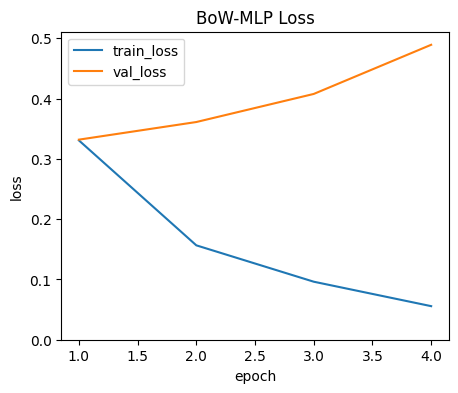

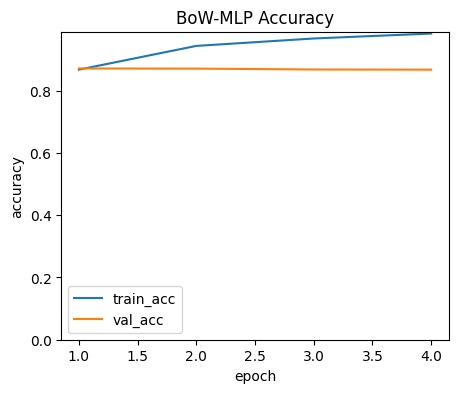

In [27]:
plt.figure(figsize=(5,4))
plt.plot(history_bow['epoch'], history_bow['train_loss'], label='train_loss')
plt.plot(history_bow['epoch'], history_bow['val_loss'], label='val_loss')
plt.ylim(bottom=0)
plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.title('BoW-MLP Loss'); plt.show()

plt.figure(figsize=(5,4))
plt.plot(history_bow['epoch'], history_bow['train_acc'], label='train_acc')
plt.plot(history_bow['epoch'], history_bow['val_acc'], label='val_acc')
plt.ylim(bottom=0)
plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend(); plt.title('BoW-MLP Accuracy'); plt.show()

### See Model Predictions

In [28]:
@torch.no_grad()
def show_predictions_bow(model, dataset, n=8):
    model.eval()
    idxs = np.random.choice(len(dataset), size=n, replace=False)
    for idx in idxs:
        x, y, text = dataset[idx]
        logit = model(x.unsqueeze(0).to(device))
        prob = torch.sigmoid(logit).item()
        pred = 1 if prob >= 0.5 else 0
        correct = (pred == int(y.item()))
        print("="*80)
        print("TRUE:", int(y.item()), "| PRED:", pred, f"| PROB(positive)={prob:.3f}", "|", "✓" if correct else "✗")
        print(text[:500], ("..." if len(text) > 500 else ""))

In [29]:
@torch.no_grad()
def show_predictions_tx(model, dataset, n=8):
    model.eval()
    idxs = np.random.choice(len(dataset), size=n, replace=False)
    for idx in idxs:
        input_ids, attn_mask, tt, y, text = dataset[idx]
        logits = model(input_ids.unsqueeze(0).to(device),
                       attn_mask.unsqueeze(0).to(device))
        prob = torch.sigmoid(logits).item()
        pred = 1 if prob >= 0.5 else 0
        correct = (pred == int(y.item()))
        print("="*80)
        print("TRUE:", int(y.item()), "| PRED:", pred,
              f"| PROB(positive)={prob:.3f}", "|", "✓" if correct else "✗")
        print(text[:500], ("..." if len(text) > 500 else ""))


In [30]:
@torch.no_grad()
def show_predictions_distilbert(model, tokenizer, raw_dataset, n=8):
    model.eval()
    idxs = np.random.choice(len(raw_dataset), size=n, replace=False)
    for idx in idxs:
        item = raw_dataset[idx]
        text, label = item["text"], item["label"]
        enc = tokenizer(text, truncation=True, padding=True,
                        max_length=MAX_LEN, return_tensors="pt")
        outputs = model(**{k: v.to(model.device) for k,v in enc.items()})
        probs = torch.softmax(outputs.logits, dim=-1)[0]
        prob_pos = probs[1].item()
        pred = int(probs.argmax().item())
        correct = (pred == label)
        print("="*80)
        print("TRUE:", label, "| PRED:", pred,
              f"| PROB(positive)={prob_pos:.3f}", "|", "✓" if correct else "✗")
        print(text[:500], ("..." if len(text) > 500 else ""))


In [31]:
show_predictions_bow(bow_model, test_bow, n=5)

TRUE: 0 | PRED: 0 | PROB(positive)=0.000 | ✓
I could not believe how terrible and boring this Hollywood remake was.It's so dreadful. It easily lands a place in my top 10 worst films of 1998.About the only thing it had going for it was Bruce Willis,who should stick to action films,as a completely emotionless killer who'd kill his own mother for the right price.But I'd rather listen to Robbie Coltraine talk American for a week than listen to Richard Gere's nauseating Irish accent again.But this film is also implausible,unconvincing,uneven,un ...
TRUE: 1 | PRED: 1 | PROB(positive)=0.976 | ✓
I rented Boogie Nights last week and I could tell you, when I watched the film I had a blast. If you think that when you watch the film you will get sicked by the porn. I mean yes, if your not a porn person who can't bother being by it, than this isn't the film to see. But the thing is, the whole film isn't really about porn. Well halfway through the film is about the porn industry but the other half i

In [32]:
def best_val_acc(history):
    return max(history['val_acc']) if history['val_acc'] else None

In [33]:
results = {
    "BoW-MLP": best_val_acc(history_bow),
    # "Mini-TX (base)": best_val_acc(history_tx),
    # "Mini-TX (opt LR)": best_val_acc(history_tx_opt),
    # "DistilBERT": best_val_acc(history_distilbert) if 'val_acc' in history_distilbert else None,
}

results

{'BoW-MLP': 0.8707999999809265}

## Build an Improved Model (Mini‑Transformer)
This model follows a standard Transformer encoder blueprint, but scaled down:

```
Token Embedding
+ Positional Embedding
↓
N × [ Multi-Head Self-Attention + Feed-Forward Network ]
↓
Masked Mean Pooling
↓
Classifier Head → Single Sentiment Logit
```

In [34]:
# A small Transformer encoder trained from scratch using the HF tokenizer vocab.
# Architecture: Token Embedding + Positional Embedding -> N x (Self-Attn + FFN) -> mean pool -> Linear(1)
class MiniTransformer(nn.Module):
    def __init__(self, vocab_size, d_model=128, nhead=4, num_layers=2, dim_feedforward=256, dropout=0.1, max_len=512):
        super().__init__()

        # token embedding: Converts token IDs into dense vectors of size d_model
        self.tok_emb = nn.Embedding(vocab_size, d_model)

        # positional embedding: Injects positional information so the model can understand word order
        self.pos_emb = nn.Embedding(max_len, d_model)

        #
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward, dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1)
        )
        self.max_len = max_len

    def forward(self, input_ids, attention_mask):
        B, L = input_ids.shape
        positions = torch.arange(0, L, device=input_ids.device).unsqueeze(0).expand(B, L)
        x = self.tok_emb(input_ids) + self.pos_emb(positions)
        # Do NOT pass src_key_padding_mask (MPS nested-tensor fast path can fail)
        x = self.encoder(x)  # <— no mask here
        lengths = attention_mask.sum(dim=1).clamp(min=1).unsqueeze(1)
        pooled = (x * attention_mask.unsqueeze(-1)).sum(dim=1) / lengths
        logit = self.classifier(pooled).squeeze(1)
        return logit

In [35]:
#
# TRAIN IT
#
mini_tx = MiniTransformer(vocab_size=tokenizer.vocab_size, d_model=128, nhead=4, num_layers=2, dim_feedforward=256, dropout=0.1, max_len=MAX_LEN).to(device)
opt_tx = make_optimizer(mini_tx, lr=1e-3, kind='AdamW')
mini_tx

MiniTransformer(
  (tok_emb): Embedding(30522, 128)
  (pos_emb): Embedding(384, 128)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=1, bias=True)
  )
)

### Train Mini‑Transformer

In [36]:
@torch.no_grad()
def evaluate_tx(model, dataloader, loss_fn, device):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0
    n = 0
    for input_ids, attn_mask, tt, Y, _ in dataloader:
        input_ids, attn_mask, Y = input_ids.to(device), attn_mask.to(device), Y.to(device)
        logits = model(input_ids, attn_mask)
        loss = loss_fn(logits, Y)
        acc = binary_accuracy_from_logits(logits, Y)
        b = input_ids.size(0)
        total_loss += loss.item() * b
        total_acc  += acc * b
        n += b
    return total_loss / n, total_acc / n

def train_one_epoch_tx(model, dataloader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0.0
    total_acc = 0.0
    n = 0
    for input_ids, attn_mask, tt, Y, _ in dataloader:
        input_ids, attn_mask, Y = input_ids.to(device), attn_mask.to(device), Y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(input_ids, attn_mask)
        loss = loss_fn(logits, Y)
        loss.backward()
        optimizer.step()
        acc = binary_accuracy_from_logits(logits, Y)
        b = input_ids.size(0)
        total_loss += loss.item() * b
        total_acc  += acc * b
        n += b
    return total_loss / n, total_acc / n

def train_model_tx(model, optimizer, loss_fn, train_loader, val_loader, device, epochs, tag):
    history = {'epoch': [], 'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best = {'val_loss': float('inf'), 'state_dict': None, 'epoch': -1}
    for ep in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch_tx(model, train_loader, loss_fn, optimizer, device)
        val_loss, val_acc = evaluate_tx(model, val_loader, loss_fn, device)
        history['epoch'].append(ep)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        if val_loss < best['val_loss']:
            best = {'val_loss': val_loss, 'state_dict': copy.deepcopy(model.state_dict()), 'epoch': ep}
        print(f"[{tag}] Epoch {ep:02d}/{epochs} | "
              f"train_loss={tr_loss:.4f} val_loss={val_loss:.4f} | "
              f"train_acc={tr_acc:.3f} val_acc={val_acc:.3f}")
    return history, best

In [37]:
#
# TRAIN IT
#
EPOCHS_TX = 4
history_tx, best_tx = train_model_tx(mini_tx, opt_tx, loss_fn, train_loader_tx, test_loader_tx, device, EPOCHS_TX, tag="Mini-TX")

[Mini-TX] Epoch 01/4 | train_loss=0.5679 val_loss=0.4512 | train_acc=0.678 val_acc=0.787
[Mini-TX] Epoch 02/4 | train_loss=0.3710 val_loss=0.3821 | train_acc=0.837 val_acc=0.829
[Mini-TX] Epoch 03/4 | train_loss=0.2784 val_loss=0.3667 | train_acc=0.887 val_acc=0.844
[Mini-TX] Epoch 04/4 | train_loss=0.2170 val_loss=0.3838 | train_acc=0.915 val_acc=0.845


In [38]:
#
# SAVE IT
#
torch.save(best_tx['state_dict'], os.path.join(RUN_DIR, 'best_mini_tx.pt'))

### Optimization Experiments (best weights, LR range test)
NOTE:
- uncomment the below cells ro run these. I opted to comment them in my last notebook run in order to skip this specific effort & move on to the distillbert model.

In [39]:
# # Restore best weights for mini‑transformer and run a LR range test (1 epoch each)
mini_tx_best = MiniTransformer(vocab_size=tokenizer.vocab_size, d_model=128, nhead=4, num_layers=2, dim_feedforward=256, dropout=0.1, max_len=MAX_LEN).to(device)
mini_tx_best.load_state_dict(torch.load(os.path.join(RUN_DIR, 'best_mini_tx.pt'), map_location=device))

<All keys matched successfully>

In [40]:
LR_LIST = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
def one_epoch_for_lr_tx(model, lr):
    tmp = copy.deepcopy(model)
    opt = make_optimizer(tmp, lr=lr, kind='AdamW')
    tr_loss, tr_acc = train_one_epoch_tx(tmp, train_loader_tx, loss_fn, opt, device)
    val_loss, val_acc = evaluate_tx(tmp, test_loader_tx, loss_fn, device)
    return {'lr': lr, 'train_loss': tr_loss, 'train_acc': tr_acc, 'val_loss': val_loss, 'val_acc': val_acc}

lr_results = []
for lr in LR_LIST:
    metrics = one_epoch_for_lr_tx(mini_tx_best, lr)
    lr_results.append(metrics)
    print(metrics)

best_lr = min(lr_results, key=lambda d: d['val_loss'])['lr']
print('Best LR from sweep:', best_lr)

{'lr': 0.0001, 'train_loss': 0.19801912074804306, 'train_acc': 0.92528, 'val_loss': 0.39574219678878786, 'val_acc': 0.8452}
{'lr': 0.0003, 'train_loss': 0.19998785735607147, 'train_acc': 0.9250400000572204, 'val_loss': 0.3900201363182068, 'val_acc': 0.8446}
{'lr': 0.001, 'train_loss': 0.21663408816814422, 'train_acc': 0.9163600000190735, 'val_loss': 0.4059358750915527, 'val_acc': 0.8322}
{'lr': 0.003, 'train_loss': 0.2930120093154907, 'train_acc': 0.8806399999809266, 'val_loss': 0.43247335841178897, 'val_acc': 0.8100000000572205}
{'lr': 0.01, 'train_loss': 0.6552965106201172, 'train_acc': 0.6494800000190735, 'val_loss': 0.751792769317627, 'val_acc': 0.5775599999952317}
Best LR from sweep: 0.0003


### Re-Training with Best LR

In [41]:
# Retrain Mini‑TX from scratch with best LR
mini_tx_opt = MiniTransformer(vocab_size=tokenizer.vocab_size, d_model=128, nhead=4, num_layers=2, dim_feedforward=256, dropout=0.1, max_len=MAX_LEN).to(device)
opt_best = make_optimizer(mini_tx_opt, lr=best_lr, kind='AdamW')
history_tx_opt, best_tx_opt = train_model_tx(mini_tx_opt, opt_best, loss_fn, train_loader_tx, test_loader_tx, device, epochs=EPOCHS_TX, tag=f"Mini-TX-opt(lr={best_lr})")

[Mini-TX-opt(lr=0.0003)] Epoch 01/4 | train_loss=0.6402 val_loss=0.5406 | train_acc=0.615 val_acc=0.729
[Mini-TX-opt(lr=0.0003)] Epoch 02/4 | train_loss=0.4781 val_loss=0.4566 | train_acc=0.770 val_acc=0.784
[Mini-TX-opt(lr=0.0003)] Epoch 03/4 | train_loss=0.4052 val_loss=0.4245 | train_acc=0.816 val_acc=0.806
[Mini-TX-opt(lr=0.0003)] Epoch 04/4 | train_loss=0.3522 val_loss=0.4152 | train_acc=0.848 val_acc=0.813


### Saving

In [42]:
torch.save(best_tx_opt['state_dict'], os.path.join(RUN_DIR, 'best_mini_tx_opt.pt'))

## Pretrained DistilBERT Fine-Tuning
Here, this fine-tunes a pre-trained encoder (`distilbert-base-uncased`) for binary sentiment.  
This typically outperforms BoW and scratch Mini-Transformer on IMDB.

In [43]:
# PRETRAINED_NAME = "distilbert-base-uncased"
PRETRAINED_NAME = "distilroberta-base"

# === Audit sequence lengths to set MAX_LEN smartly ===
def count_tokens(ex):
    return len(tokenizer_pt(ex["text"], truncation=False)["input_ids"])

# If the 95th percentile is well below 128,
# drop MAX_LEN (e.g., to 96). If many are longer, consider 160.

In [44]:

# Tokenizer / model
tokenizer_pt = AutoTokenizer.from_pretrained(PRETRAINED_NAME, use_fast=True)
model_pt     = AutoModelForSequenceClassification.from_pretrained(PRETRAINED_NAME, num_labels=2)

lengths = [count_tokens({"text": t}) for t in imdb["train"]["text"][:5000]]  # sample 5k for speed
pct = np.percentile(lengths, [50, 75, 90, 95, 98, 99])
print("Token length percentiles:", dict(zip([50,75,90,95,98,99], pct)))

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at distilroberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Token indices sequence length is longer than the specified maximum sequence length for this model (680 > 512). Running this sequence through the model will result in indexing errors


Token length percentiles: {50: np.float64(224.0), 75: np.float64(356.0), 90: np.float64(567.0), 95: np.float64(738.0), 98: np.float64(983.0199999999995), 99: np.float64(1174.0300000000007)}


In [45]:
# Tokenize dataset with the same MAX_LEN you used elsewhere

#
# RE-ENABLE in local jupyter notebook env
#
# def tok_fn(ex):
#     return tokenizer_pt(ex["text"], truncation=True, padding=False, max_length=MAX_LEN)

def clean_text(s: str) -> str:
    s = re.sub(r"<br\\s*/?>", " ", s)
    s = re.sub(r"\\n", " ", s)
    s = re.sub(r"\\t", " ", s)
    s = re.sub(r"\\s+", " ", s).strip()
    return s

def apply_clean(ex):
    ex["text"] = clean_text(ex["text"])
    return ex

imdb_clean = imdb.map(apply_clean)

#
# re-enablbe in local jupyter notebook env
#
imdb_tok = imdb_clean.map(tok_fn, batched=True, remove_columns=[c for c in imdb["train"].column_names if c not in ("text","label")]+["text"])
imdb_tok = imdb_tok.rename_column("label", "labels")
collator = DataCollatorWithPadding(tokenizer_pt)

#
# original
#
# def compute_metrics(eval_pred):
#     logits, labels = eval_pred
#     preds = (1 / (1 + np.exp(-logits)))[:, 1]  # sigmoid on class-1 logit for binary
#     hard = (preds >= 0.5).astype(int)
#     return {
#         "accuracy": accuracy_score(labels, hard),
#         "f1": f1_score(labels, hard),
#         "precision": precision_score(labels, hard),
#         "recall": recall_score(labels, hard),
#     }

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)   # pick class 0/1

    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary",
        zero_division=0,   # don't blow up when one class is missing
    )

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": prec,
        "recall": rec,
    }

PT_BATCH   = 16          # safe default for laptop; raise if memory allows
PT_EPOCHS  = 4
PT_LR      = 2e-5
GRAD_ACCUM = 2
WARMUP     = 0.1
OUTDIR     = "./runs_imdb_distilbert"

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [46]:
model_pt.device

device(type='cpu')

In [47]:
next(model_pt.parameters()).device

device(type='cpu')

In [48]:
imdb_tok = imdb_tok.shuffle(seed=42)

TRAIN_LIMIT_PT = 5000
VAL_LIMIT_PT   = 2000

train_ds_pt = imdb_tok["train"].select(range(TRAIN_LIMIT_PT))
val_ds_pt   = imdb_tok["test"].select(range(VAL_LIMIT_PT))

In [49]:
print("Train labels:", Counter(train_ds_pt["labels"]))
print("Val labels:",   Counter(val_ds_pt["labels"]))

Train labels: Counter({1: 2506, 0: 2494})
Val labels: Counter({1: 1000, 0: 1000})


In [50]:
args = TrainingArguments(
    output_dir=OUTDIR,
    per_device_train_batch_size=PT_BATCH,
    per_device_eval_batch_size=PT_BATCH,
    num_train_epochs=PT_EPOCHS,
    learning_rate=PT_LR,
    weight_decay=0.01,

    # Eval/Save/Logging

    # TODO: DEAL WITH THIS LATE
    # evaluation_strategy="epoch",
    # save_strategy="epoch",
    # load_best_model_at_end=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,

    metric_for_best_model="accuracy",
    greater_is_better=True,
    logging_steps=50,
    report_to="none",

    # Stability/perf knobs (macOS MPS safe)
    dataloader_num_workers=0,
    dataloader_pin_memory=False,
    gradient_accumulation_steps=GRAD_ACCUM,
    fp16=False, bf16=False,
)

# Early stopping on the Trainer
# stop if val metric doesn't improve for 2 evals
es_cb = EarlyStoppingCallback(early_stopping_patience=2)

#
# NOTE:
# below uses the FULL DATASET to train
#
# trainer = Trainer(
#     model=model_pt,
#     args=args,
#     train_dataset=imdb_tok["train"],
#     eval_dataset=imdb_tok["test"],
#     tokenizer=tokenizer_pt,
#     data_collator=collator,
#     compute_metrics=compute_metrics,
#     callbacks=[es_cb],
# )

#
# NOTE: here's the significantly-smaller dataset to use for building the trainer
#

trainer = Trainer(
    model=model_pt,
    args=args,
    train_dataset=train_ds_pt,
    eval_dataset=val_ds_pt,
    tokenizer=tokenizer_pt,
    data_collator=collator,
    compute_metrics=compute_metrics,
    # TODO: put back with above evaluation_strategy fix
    callbacks=[es_cb],
)

/tmp/ipython-input-3370710659.py:54: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [51]:
print("Train labels:", Counter(train_ds_pt["labels"]))
print("Val labels  :", Counter(val_ds_pt["labels"]))

Train labels: Counter({1: 2506, 0: 2494})
Val labels  : Counter({1: 1000, 0: 1000})


In [52]:
print("Full train size:", len(imdb_tok["train"]))
print("Full test size :", len(imdb_tok["test"]))
print("PT train slice :", len(train_ds_pt))
print("PT val slice   :", len(val_ds_pt))

Full train size: 25000
Full test size : 25000
PT train slice : 5000
PT val slice   : 2000


In [54]:
for entry in trainer.state.log_history:
    print(entry)

In [55]:
print("Train label distribution:", Counter(train_ds_pt["labels"]))
print("Val label distribution  :", Counter(val_ds_pt["labels"]))

Train label distribution: Counter({1: 2506, 0: 2494})
Val label distribution  : Counter({1: 1000, 0: 1000})


In [56]:

# TRAIN
#
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.301500,0.223382,0.907500,0.907639,0.906281,0.909000
2,0.186800,0.269661,0.896000,0.903075,0.845550,0.969000
3,0.127200,0.240639,0.919500,0.916624,0.950591,0.885000
4,0.083900,0.273644,0.922000,0.923828,0.902672,0.946000


In [57]:
#
# EVAL
#
eval_result = trainer.evaluate()
print("DistilBERT eval:", eval_result)

DistilBERT eval: {'eval_loss': 0.27364423871040344, 'eval_accuracy': 0.922, 'eval_f1': 0.923828125, 'eval_precision': 0.9026717557251909, 'eval_recall': 0.946, 'eval_runtime': 21.8509, 'eval_samples_per_second': 91.529, 'eval_steps_per_second': 5.721, 'epoch': 4.0}


In [58]:
history_distilbert = {
    'epoch': [],
    'train_loss': [],
    'val_loss': [],   # was eval_loss
    'val_acc': [],    # was eval_accuracy
}

In [59]:
for e, loss, acc in zip(
    history_distilbert["epoch"],
    history_distilbert["val_loss"],
    history_distilbert["val_acc"],
):
    print(f"Epoch {e:.1f}: val_loss={loss:.4f}, val_acc={acc:.4f}")

In [60]:
# === Build history_distilbert from trainer logs ===
for entry in trainer.state.log_history:
    if 'eval_loss' in entry:
        history_distilbert['epoch'].append(entry['epoch'])
        history_distilbert['val_loss'].append(entry['eval_loss'])
        # Trainer logs eval_accuracy when compute_metrics() returns "accuracy"
        if 'eval_accuracy' in entry:
            history_distilbert['val_acc'].append(entry['eval_accuracy'])

history_distilbert

{'epoch': [1.0, 2.0, 3.0, 4.0, 4.0],
 'train_loss': [],
 'val_loss': [0.22338177263736725,
  0.2696611285209656,
  0.24063895642757416,
  0.27364423871040344,
  0.27364423871040344],
 'val_acc': [0.9075, 0.896, 0.9195, 0.922, 0.922]}

## Model Comparison Plots

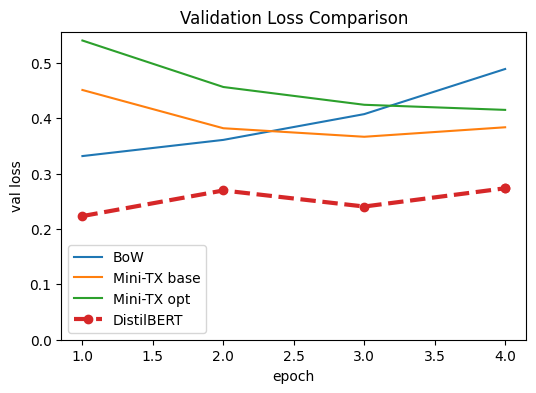

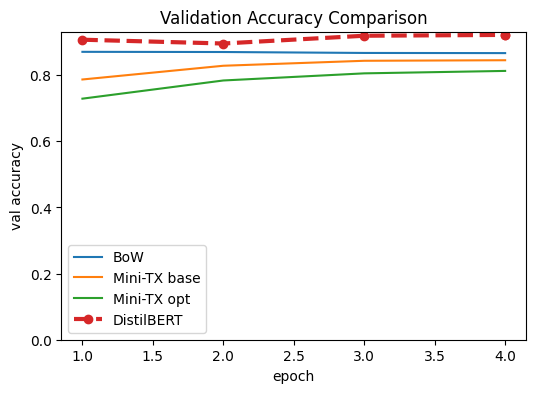

In [61]:
plt.figure(figsize=(6,4))
plt.plot(history_bow['epoch'], history_bow['val_loss'], label='BoW')
plt.plot(history_tx['epoch'],  history_tx['val_loss'],  label='Mini-TX base')
plt.plot(history_tx_opt['epoch'], history_tx_opt['val_loss'], label='Mini-TX opt')
plt.plot(history_distilbert['epoch'], history_distilbert['val_loss'], label='DistilBERT', linewidth=3, linestyle='--', marker='o')

plt.ylim(bottom=0)
plt.xlabel('epoch'); plt.ylabel('val loss')
plt.title('Validation Loss Comparison')
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history_bow['epoch'], history_bow['val_acc'], label='BoW')
plt.plot(history_tx['epoch'],  history_tx['val_acc'],  label='Mini-TX base')
plt.plot(history_tx_opt['epoch'], history_tx_opt['val_acc'], label='Mini-TX opt')
plt.plot(history_distilbert['epoch'], history_distilbert['val_acc'],label='DistilBERT', linewidth=3, linestyle='--', marker='o')

plt.ylim(bottom=0)
plt.xlabel('epoch'); plt.ylabel('val accuracy')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.show()


In [62]:
for k, v in history_distilbert.items():
    print(k, len(v), "values")

epoch 5 values
train_loss 0 values
val_loss 5 values
val_acc 5 values


In [63]:
# Save LR sweep results
with open(os.path.join(RUN_DIR, 'lr_sweep_results_mini_tx.json'), 'w') as f:
    json.dump({'results': lr_results}, f, indent=2)
print('Saved LR sweep results to runs_imdb/lr_sweep_results_mini_tx.json')

Saved LR sweep results to runs_imdb/lr_sweep_results_mini_tx.json


## 14) Summary Markdown

### What improved performance most?
- **Mini‑Transformer** tends to outperform the **BoW‑MLP** by leveraging token embeddings, positional information, and self‑attention to capture long‑range dependencies.
- **Learning‑rate tuning** helped stabilize training and improved validation metrics.

### Role of LR tuning
- A short **LR range test** (1 epoch per LR candidate) gives a quick empirical signal for a good starting LR.
- Re‑training with the chosen LR typically converges faster and/or to a better minimum.

### Architecture effects
- **BoW** ignores word order and context, but is fast and strong with enough data.
- **Transformers** retain order via positional embeddings and model interactions via attention, often yielding better generalization for text tasks.

> Further improvements: deeper/wider transformer, dropout tuning, weight decay, larger max length, better tokenization strategies, or initializing from a pre‑trained encoder (e.g., DistilBERT) for stronger results.

## 15) Optional Additions

In [64]:
# 1) LR Schedulers (e.g., CosineAnnealingLR or OneCycleLR)
#   sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt_best, T_max=EPOCHS_TX)

# 2) Text Augmentation (lightweight, e.g., word dropout on BoW tokens)
# def word_dropout(tokens, p=0.05):
#     return [t for t in tokens if random.random() > p]

# 3) Batch Size experiments
# BATCH_SIZE = 256 (if memory allows), then rebuild loaders

# 4) Save/Load whole models (less portable than state_dict)
# torch.save(mini_tx_opt, os.path.join(RUN_DIR, 'mini_tx_full.pth'))
# model2 = torch.load(os.path.join(RUN_DIR, 'mini_tx_full.pth'), map_location=device)

# 5) (Stretch) Hugging Face Trainer with a pre‑trained model (e.g., distilbert-base-uncased)
# from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
# model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)
# (prepare tokenized DatasetDict, then use Trainer for fine‑tuning)

## Model In Action
Here, 2 sentences with clearly positive & negative sentiment tested with the model, and the resulting sentiment printed:

In [65]:
label_names = {0: "negative", 1: "positive"}

# Use the best model from Trainer
best_model = trainer.model.to(device)
best_model.eval()

def predict_sentiment(text: str):
    """Run a single text string through DistilBERT and return label + probs."""
    inputs = tokenizer_pt(
        text,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
    ).to(device)

    with torch.no_grad():
        outputs = best_model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]

    pred_id = int(probs.argmax())
    return {
        "text": text,
        "pred_label_id": pred_id,
        "pred_label": label_names[pred_id],
        "prob_negative": float(probs[0]),
        "prob_positive": float(probs[1]),
    }

# Example sentences
examples = [
    "This movie was an absolute disaster. The acting was wooden and the plot made no sense.",
    "I loved this film! The story was beautiful and I couldn't stop smiling afterwards.",
]

for s in examples:
    res = predict_sentiment(s)
    print("Text:", res["text"])
    print(f"Predicted: {res['pred_label']} "
          f"(neg={res['prob_negative']:.3f}, pos={res['prob_positive']:.3f})")
    print("-" * 70)

Text: This movie was an absolute disaster. The acting was wooden and the plot made no sense.
Predicted: negative (neg=0.999, pos=0.001)
----------------------------------------------------------------------
Text: I loved this film! The story was beautiful and I couldn't stop smiling afterwards.
Predicted: positive (neg=0.003, pos=0.997)
----------------------------------------------------------------------
